<a href="https://colab.research.google.com/github/Rashilajayasinghe/DomainSpecified_AI_Assistant/blob/Recommandation_SYS/BestcourseRecSys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [152]:
import pandas as pd
import matplotlib as mp

In [153]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [154]:
df = pd.read_csv('/content/sample_data/final_dataset.csv')

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9892 entries, 0 to 9891
Data columns (total 38 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Stage                                   9892 non-null   int64  
 1   hours_per_week                          9892 non-null   float64
 2   academic_stress                         9892 non-null   int64  
 3   struggle_with_managing                  9892 non-null   int64  
 4   start_assignments_closer_deadline       9892 non-null   int64  
 5   Skill_Programming                       9892 non-null   int64  
 6   Skill_Math                              9892 non-null   int64  
 7   Skill_Technical_Comm                    9892 non-null   int64  
 8   Skill_Web_Development                   9892 non-null   int64  
 9   Grade_CM1601                            9892 non-null   float64
 10  Grade_CM1602                            9892 non-null   floa

In [156]:
df.tail()

,Stage,hours_per_week,academic_stress,struggle_with_managing,start_assignments_closer_deadline,Skill_Programming,Skill_Math,Skill_Technical_Comm,Skill_Web_Development,Grade_CM1601,...,Grade_CM4601,Grade_CM4606,Grade_CM4603,Year1_GPA,Year2_GPA,Year3_GPA,Year4_GPA,Balancing multiple courses or projects,Not knowing how to prioritize task,Starting tasks too late
9887,4,7.5,2,1,1,5,4,5,5,4.0,...,4.0,3.0,0.0,3.250,3.500,3.875,3.375,0,1,0
9888,4,12.5,1,1,1,5,4,4,5,4.0,...,4.0,0.0,3.0,3.750,3.625,3.750,3.875,1,0,0
9889,4,12.5,1,1,1,4,5,5,5,4.0,...,4.0,4.0,0.0,3.375,3.625,4.000,4.000,0,0,1
9890,4,12.5,1,1,1,5,5,5,4,4.0,...,3.0,0.0,3.0,3.750,3.250,3.000,3.250,1,0,0
9891,3,7.5,1,1,1,4,4,4,4,4.0,...,0.0,0.0,0.0,3.750,3.750,3.000,0.000,0,0,0


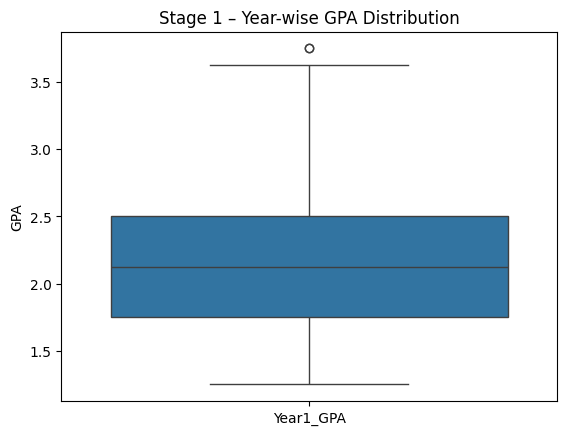

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

stage1 = df[df['Stage'] == 1]

sns.boxplot(data=stage1[['Year1_GPA']])
plt.title("Stage 1 – Year-wise GPA Distribution")
plt.ylabel("GPA")
plt.show()



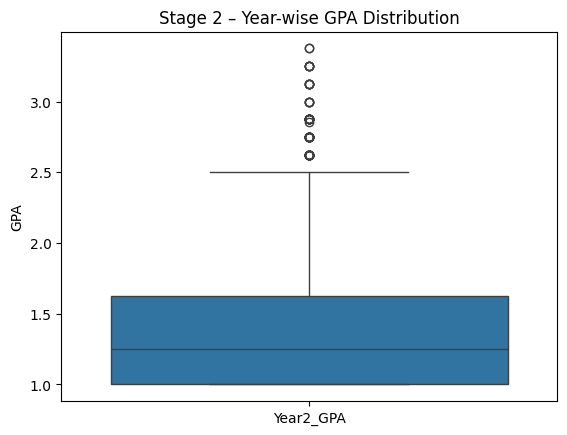

In [158]:
stage2 = df[df['Stage'] == 2]

sns.boxplot(data=stage2[['Year2_GPA']])
plt.title("Stage 2 – Year-wise GPA Distribution")
plt.ylabel("GPA")
plt.show()


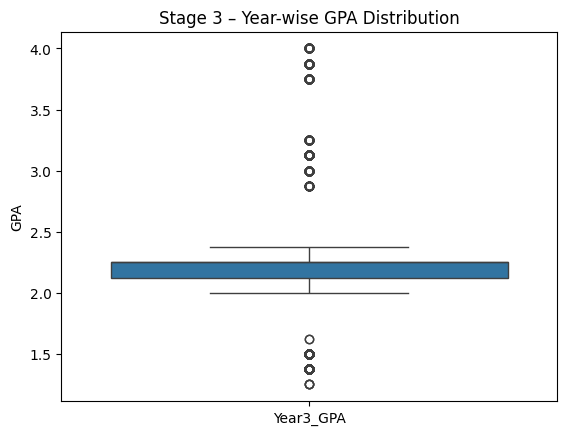

In [159]:
stage3 = df[df['Stage'] == 3]

sns.boxplot(data=stage3[['Year3_GPA']])
plt.title("Stage 3 – Year-wise GPA Distribution")
plt.ylabel("GPA")
plt.show()


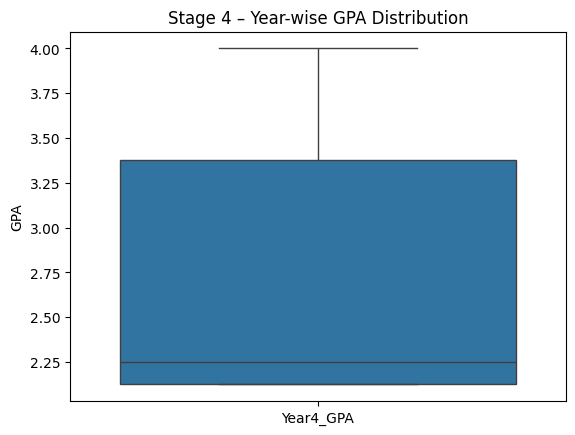

In [160]:
stage4 = df[df['Stage'] == 4]

sns.boxplot(data=stage4[['Year4_GPA']])
plt.title("Stage 4 – Year-wise GPA Distribution")
plt.ylabel("GPA")
plt.show()


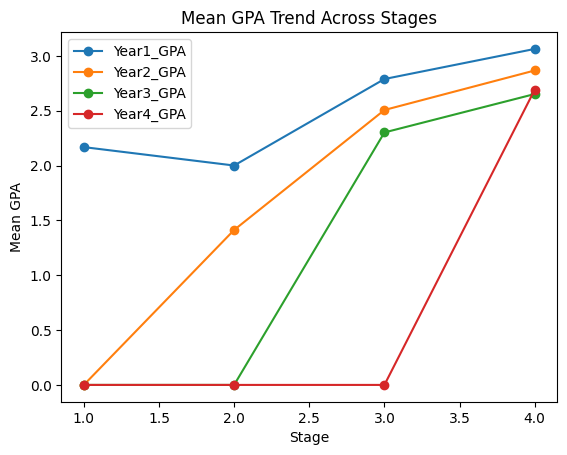

In [161]:
df.groupby('Stage')[['Year1_GPA','Year2_GPA','Year3_GPA','Year4_GPA']].mean().plot(marker='o')
plt.title("Mean GPA Trend Across Stages")
plt.ylabel("Mean GPA")
plt.show()


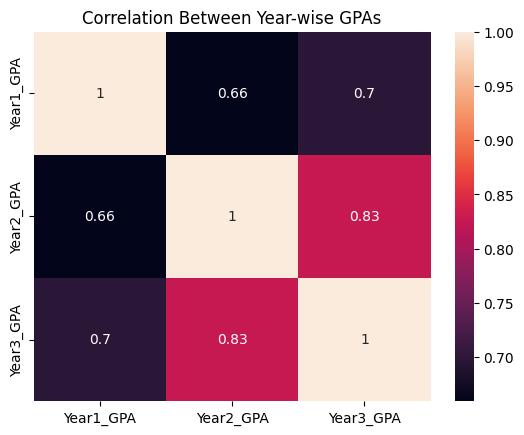

In [162]:
sns.heatmap(df[['Year1_GPA','Year2_GPA','Year3_GPA']].corr(), annot=True)
plt.title("Correlation Between Year-wise GPAs")
plt.show()


Year 3 Elective

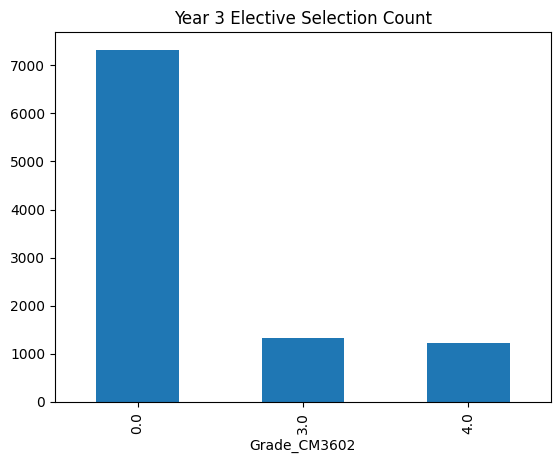

In [163]:
df['Grade_CM3602'].value_counts().plot(kind='bar')
plt.title("Year 3 Elective Selection Count")
plt.show()


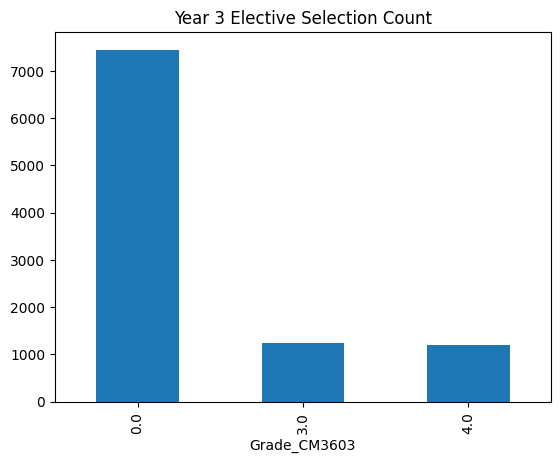

In [164]:
df['Grade_CM3603'].value_counts().plot(kind='bar')
plt.title("Year 3 Elective Selection Count")
plt.show()

Year 4 Elective

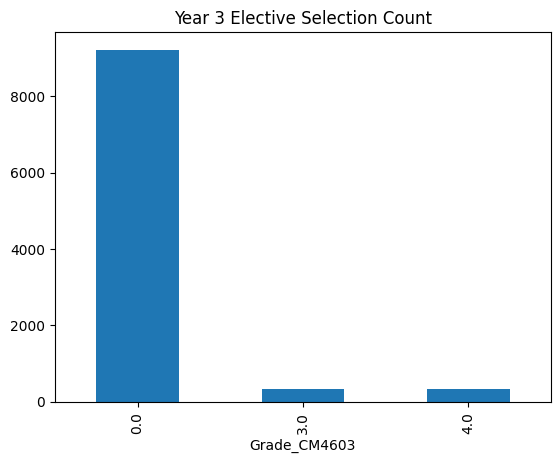

In [165]:
df['Grade_CM4603'].value_counts().plot(kind='bar')
plt.title("Year 3 Elective Selection Count")
plt.show()

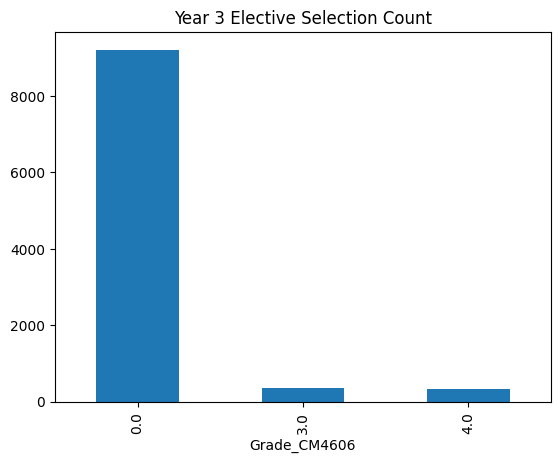

In [166]:
df['Grade_CM4606'].value_counts().plot(kind='bar')
plt.title("Year 3 Elective Selection Count")
plt.show()

CF based on Cosine Similarity Matrix

In [167]:
similarity_features = ['Year1_GPA', 'Year2_GPA']


In [168]:
similarity_features = ['Year1_GPA', 'Year2_GPA', 'Year3_GPA']


In [169]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[similarity_features])


In [170]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(scaled_features)


In [171]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df.index,
    columns=df.index
)


In [172]:
pred_cm3603 = recommend_year3(
    student_idx=2,
    df=df,
    similarity_df=similarity_df,
    elective_col='Grade_CM3603'
)

pred_cm3604 = recommend_year3(
    student_idx=2,
    df=df,
    similarity_df=similarity_df,
    elective_col='Grade_CM3602'
)


In [173]:
if pred_cm3603 > pred_cm3604:
    recommendation = "CM3603"
else:
    recommendation = "CM3602"

recommendation


'CM3602'

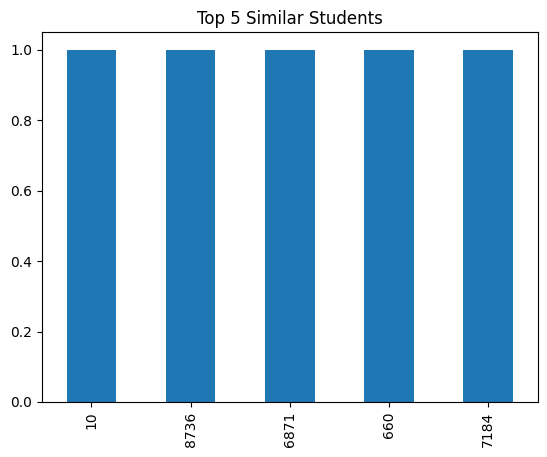

In [174]:
similarity_df.iloc[10].sort_values(ascending=False)[1:6].plot(kind='bar')
plt.title("Top 5 Similar Students")
plt.show()


CF based on KNN

In [175]:
X = df[['Year1_GPA', 'Year2_GPA']]
X_scaled = StandardScaler().fit_transform(X)


In [176]:
param_grid = {
    'n_neighbors': list(range(50, 501, 50))
}
print(param_grid)

{'n_neighbors': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]}


In [177]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    cv=5,  # Using 5-fold cross-validation
    scoring='accuracy', # Using accuracy as the scoring metric
    n_jobs=-1 # Use all available cores
)

grid_search.fit(X_scaled, df['Stage'])

print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

Best parameters found:  {'n_neighbors': 50}
Best accuracy found:  0.7436269913975406


In [178]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Get the best n_neighbors from GridSearchCV
best_n_neighbors = grid_search.best_params_['n_neighbors']
print(f"Using best n_neighbors: {best_n_neighbors}")

# Re-instantiate the NearestNeighbors model with the best n_neighbors
knn_optimized = NearestNeighbors(
    n_neighbors=best_n_neighbors,
    metric='cosine'
)
knn_optimized.fit(X_scaled)

# Define the get_recommendation_numeric function to use the optimized knn model
def get_recommendation_numeric_optimized(student_index):
    distances, indices = knn_optimized.kneighbors(X_scaled[student_index].reshape(1, -1))
    neighbors = df.iloc[indices[0]]
    avg_grade = neighbors[neighbors['Grade_CM3603'] > 0]['Grade_CM3603'].mean()
    if pd.isna(avg_grade):
        return 0.0
    return avg_grade

# Re-evaluate the recommendation system for CM3603 with the optimized model
test_data = df[df['Grade_CM3603'] > 0].head(100)
actuals = test_data['Grade_CM3603']
predictions_optimized = [get_recommendation_numeric_optimized(idx) for idx in test_data.index]

mae_optimized = mean_absolute_error(actuals, predictions_optimized)
mse_optimized = mean_squared_error(actuals, predictions_optimized)
rmse_optimized = np.sqrt(mse_optimized)

print(f"\n--- Accuracy Results for CM3603 with optimized n_neighbors ({best_n_neighbors}) ---")
print(f"Mean Absolute Error (MAE): {mae_optimized:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_optimized:.4f}")

Using best n_neighbors: 50

--- Accuracy Results for CM3603 with optimized n_neighbors (50) ---
Mean Absolute Error (MAE): 0.4707
Root Mean Squared Error (RMSE): 0.4853


In [179]:
def get_recommendation_for_student(student_index, df, X_scaled, knn_model):
    # 1. Find neighbors for the specific student index provided
    distances, indices = knn_model.kneighbors(X_scaled[student_index].reshape(1, -1))

    # 2. Get the data for those neighbors
    neighbors = df.iloc[indices[0]]

    # 3. Calculate average grades for the two electives among neighbors
    # We filter for > 0 to ensure we only average students who actually took the course
    avg_grade_3602 = neighbors[neighbors['Grade_CM3602'] > 0]['Grade_CM3602'].mean()
    avg_grade_3603 = neighbors[neighbors['Grade_CM3603'] > 0]['Grade_CM3603'].mean()

    # 4. Handle cases where no neighbors took a specific course (NaN check)
    avg_grade_3602 = 0 if pd.isna(avg_grade_3602) else avg_grade_3602
    avg_grade_3603 = 0 if pd.isna(avg_grade_3603) else avg_grade_3603

    # 5. Logic to decide recommendation
    if avg_grade_3602 > avg_grade_3603:
        return f"Student {student_index}: Recommend CM3602 (IoT) - Predicted Score: {avg_grade_3602:.2f}"
    else:
        return f"Student {student_index}: Recommend CM3603 (Edge AI) - Predicted Score: {avg_grade_3603:.2f}"

In [180]:
for i in range(200):
    print(get_recommendation_for_student(i, df, X_scaled, knn))

Student 0: Recommend CM3602 (IoT) - Predicted Score: 3.65
Student 1: Recommend CM3603 (Edge AI) - Predicted Score: 3.55
Student 2: Recommend CM3603 (Edge AI) - Predicted Score: 3.51
Student 3: Recommend CM3603 (Edge AI) - Predicted Score: 3.49
Student 4: Recommend CM3602 (IoT) - Predicted Score: 3.62
Student 5: Recommend CM3603 (Edge AI) - Predicted Score: 3.55
Student 6: Recommend CM3603 (Edge AI) - Predicted Score: 3.54
Student 7: Recommend CM3602 (IoT) - Predicted Score: 3.46
Student 8: Recommend CM3603 (Edge AI) - Predicted Score: 3.57
Student 9: Recommend CM3602 (IoT) - Predicted Score: 3.47
Student 10: Recommend CM3603 (Edge AI) - Predicted Score: 3.54
Student 11: Recommend CM3603 (Edge AI) - Predicted Score: 3.49
Student 12: Recommend CM3602 (IoT) - Predicted Score: 3.50
Student 13: Recommend CM3602 (IoT) - Predicted Score: 3.50
Student 14: Recommend CM3602 (IoT) - Predicted Score: 3.50
Student 15: Recommend CM3602 (IoT) - Predicted Score: 3.65
Student 16: Recommend CM3603 (Edge